# Copernicus Data Space Ecosystem (CDSE) openEO API

<a href="https://githubtocolab.com/kokkytos/gee/blob/main/Lesson8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

## Σύνδεση και ανάκτηση πληροφοριών για τα data collections

In [ ]:
import openeo # για την αλληλεπίδραση με το OpenEO API
from dotenv import load_dotenv # για την φόρτωση μεταβλητών περιβάλλοντος από .env αρχεία
from pprint import pprint # για την εκτύπωση δομών δεδομένων
from pathlib import Path # για την διαχείριση διαδρομών αρχείων
import os # για την αλληλεπίδραση με το λειτουργικό σύστημα
import geopandas as gpd # για την εργασία με γεωγραφικά δεδομένα
from openeo.processes import array_contains # για την έλεγχο αν ένα στοιχείο υπάρχει σε έναν πίνακα
from openeo.processes import clip # για την αποκοπή γεωγραφικών δεδομένων
import json # για την εργασία με JSON δεδομένα
from openeo.processes import mean, median # για τον υπολογισμό μέσου όρου και διάμεσου με το OpenEO
import xarray as xr # για την εργασία με πολυδιάστατα δεδομένα
import matplotlib.pyplot as plt # για την δημιουργία γραφημάτων
import hvplot.xarray
import matplotlib.pyplot as plt
import leafmap
import numpy as np



OUTPUT_DIR = Path("output") / 'CDSE' # φακέλος για την αποθήκευση των αποτελεσμάτων
OUTPUT_DIR.mkdir(exist_ok=True) # δημιουργία του φακέλου αν δεν υπάρχει ήδη

Το επόμενο cell κώδικα αφορά την εκτέλεση του notebook στο Google Colab, όπου απαιτείται η σύνδεση με το Google Drive για την αποθήκευση των αποτελεσμάτων και η εγκατάσταση των απαραίτητων βιβλιοθηκών.
Αν εκτελείτε το notebook τοπικά αγνοήστε αυτό το cell.

In [ ]:

try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Colab\ Notebooks/gee
    !pip install openeo python-dotenv geopandas xarray matplotlib hvplot rioxarray leafmap numpy
except:
  print("Παρακαλώ εκτελέστε το notebook στο Google Colab")

Για την εκτέλεση εντολών στο Copernicus Data Space Ecosystem μέσω του OpenEO API απαιτείται η σύνδεση και αυθεντικοποίηση. 
Αναφορικά με τις λεπτομέρειες δημιουργίας λογαριασμού και τις δυνατότητες σύνδεσης ο χρήστης μπορεί να ανατρέξει εδώ: 
[https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html)

Για την εγκατάσταση του OpenEO, οι οδηγίες είναι διαθέσιμες εδώ: [https://documentation.dataspace.copernicus.eu/APIs/openEO/Python_Client/Python.html](https://documentation.dataspace.copernicus.eu/APIs/openEO/Python_Client/Python.html)

Στο επόμενο βήμα γίνεται σύνδεση μέσω του OpenID. Κατά την κλίση της μεθόδου ορίζεται το backend του copernicus (https://openeo.dataspace.copernicus.eu).
Στο openEO, ο "backend" είναι το υπολογιστικό σύστημα νέφους που αναλαμβάνει την αποθήκευση των δορυφορικών δεδομένων, την διάθεση και διαχείριση της υπολογιστικής ισχύς και τα εργαλεία ανάλυσης δεδομένων και εκτέλεσης αλγορίθμων. 

In [40]:
# Σύνδεση και αυθεντικοποίηση με το OpenEO API στο Copernicus Data Space
# Connect
conn = openeo.connect("https://openeo.dataspace.copernicus.eu") # https://documentation.dataspace.copernicus.eu/APIs/openEO/authentication.html
conn.authenticate_oidc() # OpenID Connect: https://openid.net/developers/how-connect-works/

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

*Άλλη επιλογή σύνδεσης, που δεν απαιτεί την αλληλεπίδραση μέσω του browser είναι μέσω του authenticate_oidc_client_credentials*.
Σε αυτή την περίπτωση ο χρήστης θα πρέπει να δημιουργήσει τα απαραίτητα διαπιστευτήρια από εδώ: [https://shapps.dataspace.copernicus.eu/dashboard/#/account/settings](https://shapps.dataspace.copernicus.eu/dashboard/#/account/settings). 
Στο παρακάτω παράδειγμα η σύνδεση γίνεται χρησιμοποιώντας τις απαραίτητες μεταβλητές περιβάλλοντος που έχουν ορίστει στο .env αρχείο 


Στην συνέχεια αφού επιτευχθεί επιτυχώς η σύνδεση, τότε με βάση το conn object ο χρήστης μπορεί να αλληλοεπιδρά με το OpenEO API του Copernicus Data Space Ecosystem (CDSE).
Στο παρακάτω παράδειγμα καλείται η μέθοδος *list_collections()* για να ανακτήσουμε πληροφορίες για τα διαθέσιμα datasets του backend που επιλέξαμε. Για την περιήγηση στα collections και στα μεταδεδομένα τους δεν είναι απαραίτητη η σύνδεση αλλά για την εκτέλεση διαδικασιών και την εξαγωγή δεδομένων είναι.

In [41]:
conn.list_collections()

[{'description': 'Copernicus Global 30 meter Digital Elevation Model dataset.',
  'extent': {'spatial': {'bbox': [[-180, -90, 180, 90]]},
   'temporal': {'interval': [['2010-12-12T00:00:00Z',
      '2015-01-16T00:00:00Z']]}},
  'id': 'COPERNICUS_30',
  'keywords': ['Copernicus', 'ESA', 'Satellite', 'Global', 'DEM', 'EU', 'EC'],
  'license': 'proprietary',
  'links': [{'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog/items',
    'rel': 'items',
    'type': 'application/geo+json'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://dataspace.copernicus.eu/sites/default/files/media/files/2025-06/copernicus_contributing_mission_data_access_v2_cop_dem_licenses.pdf',
    'rel': 'license',
    'title': 'Legal notice on the use of Copernicus DEM Data and Service Information',
    'type': 'application/pdf'},
   {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'title': 'Queryables',
    'type': 'application/schema+json'}],
  'providers': [{'name': 'ESA',
    'roles': ['producer'],
    'url': 'https://dataspace.copernicus.eu/explore-data/data-collections/copernicus-contributing-missions/collections-description/COP-DEM'},
   {'name': 'European Commission',
    'roles': ['licensor'],
    'url': 'https://commission.europa.eu/'},
   {'name': 'CloudFerro',
    'roles': ['host', 'processor'],
    'url': 'https://cloudferro.com/'}],
  'stac_extensions': ['https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
   'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
   'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
   'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.1.0/schema.json',
   'https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/storage/v2.0.0/schema.json'],
  'stac_version': '1.1.0',
  'title': 'Copernicus Global 30 meter Digital Elevation Model dataset.'},
 {'description': 'Sentinel 3 imagery captured by OLCI sensor',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2016-04-17T11:33:13Z', None]]}},
  'id': 'SENTINEL3_OLCI_L1B',
  'license': 'proprietary',
  'links': [{'href': 'https://sh.dataspace.copernicus.eu/catalog/v1/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/catalog/v1/collections/sentinel-3-olci',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/catalog/v1/collections',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/catalog/v1/collections/sentinel-3-olci/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'type': 'application/schema+json'},
   {'href': 'https://sh.dataspace.copernicus.eu/catalog/v1/collections/sentinel-3-olci/items',
    'rel': 'items',
    'type': 'application/geo+json'}],
  'providers': [],
  'stac_extensions': ['https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
   'https://stac-extensions.github.io/eo/v1.0.0/schema.json'],
  'stac_version': '1.0.0',
  'title': 'Sentinel 3 OLCI'},
 {'description': 'Sentinel 3 imagery captured by SLSTR sensor',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2016-04-17T11:33:13Z', None]]}},
  'id': 'SENTINEL3_SLSTR',
  'license': 'proprietary',
  'links': [{'href': 'http

Ενώ με την μέθοδο *list_collection_ids()* επιστρέφεται μια πιο συνοπτική λίστα που αφορά μόνο τα ids των διάφορων collections.

In [43]:
conn.list_collection_ids()

['COPERNICUS_30',
 'SENTINEL3_OLCI_L1B',
 'SENTINEL3_SLSTR',
 'SENTINEL_5P_L2',
 'LANDSAT_BIMONTHLY_MOSAIC',
 'COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON1',
 'COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON2',
 'COPERNICUS_PLANT_PHENOLOGY_INDEX',
 'ESA_WORLDCOVER_10M_2020_V1',
 'ESA_WORLDCOVER_10M_2021_V2',
 'SENTINEL1_GLOBAL_MOSAICS',
 'SENTINEL2_L2A',
 'SENTINEL2_L1C',
 'SENTINEL1_GRD',
 'SENTINEL3_SYN_L2_SYN',
 'SENTINEL3_SLSTR_L2_LST',
 'SENTINEL3_OLCI_L2_LAND',
 'SENTINEL3_OLCI_L2_WATER',
 'SENTINEL3_SYN_L2_AOD']

Η μέθοδος *describe_collection()* επιστρέφει λεπτομερείς πληροφορίες για ένα συγκεκριμένο collection (πχ για το SENTINEL2_L2A)

In [44]:
conn.describe_collection("SENTINEL2_L2A")

{'assets': {'thumbnail': {'href': 'https://s3.waw3-2.cloudferro.com/swift/v1/stac-png/S2_L2A.jpg',
   'proj:code': None,
   'proj:shape': [360, 640],
   'roles': ['thumbnail'],
   'title': 'Sentinel-2 Level-2A',
   'type': 'image/jpeg'}},
 'auth:schemes': {'oidc': {'openIdConnectUrl': 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/.well-known/openid-configuration',
   'type': 'openIdConnect'},
  's3': {'type': 's3'}},
 'bands': [{'description': 'Coastal aerosol (band 1)',
   'eo:common_name': 'coastal',
   'gsd': 60,
   'name': 'B01'},
  {'description': 'Blue (band 2)',
   'eo:common_name': 'blue',
   'gsd': 10,
   'name': 'B02'},
  {'description': 'Green (band 3)',
   'eo:common_name': 'green',
   'gsd': 10,
   'name': 'B03'},
  {'description': 'Red (band 4)',
   'eo:common_name': 'red',
   'gsd': 10,
   'name': 'B04'},
  {'description': 'Red edge 1 (band 5)',
   'eo:common_name': 'rededge071',
   'gsd': 20,
   'name': 'B05'},
  {'description': 'Red edge 2 (band 6)',
   'eo:common_name': 'rededge075',
   'gsd': 20,
   'name': 'B06'},
  {'description': 'Red edge 3 (band 7)',
   'eo:common_name': 'rededge078',
   'gsd': 20,
   'name': 'B07'},
  {'description': 'NIR 1 (band 8)',
   'eo:common_name': 'nir',
   'gsd': 10,
   'name': 'B08'},
  {'description': 'NIR 2 (band 8A)',
   'eo:common_name': 'nir08',
   'gsd': 20,
   'name': 'B8A'},
  {'description': 'NIR 3 (band 9)',
   'eo:common_name': 'nir09',
   'gsd': 60,
   'name': 'B09'},
  {'description': 'SWIR 1 (band 11)',
   'eo:common_name': 'swir16',
   'gsd': 20,
   'name': 'B11'},
  {'description': 'SWIR 2 (band 12)',
   'eo:common_name': 'swir22',
   'gsd': 20,
   'name': 'B12'}],
 'ceosard:specification': 'SR',
 'ceosard:specification_version': '5.0.1',
 'ceosard:type': 'optical',
 'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['B01',
    'B02',
    'B03',
    'B04',
    'B05',
    'B06',
    'B07',
    'B08',
    'B8A',
    'B09',
    'B11',
    'B12',
    'WVP',
    'AOT',
    'SCL',
    'sunAzimuthAngles',
    'sunZenithAngles',
    'viewAzimuthMean',
    'viewZenithMean',
    'CLD',
    'SNW']},
  't': {'extent': ['2015-06-27T10:25:31Z', None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-180, 180],
   'reference_system': {'$schema': 'https://proj.org/schemas/v0.2/projjson.schema.json',
    'area': 'World',
    'bbox': {'east_longitude': 180,
     'north_latitude': 90,
     'south_latitude': -90,
     'west_longitude': -180},
    'coordinate_system': {'axis': [{'abbreviation': 'Lat',
       'direction': 'north',
       'name': 'Geodetic latitude',
       'unit': 'degree'},
      {'abbreviation': 'Lon',
       'direction': 'east',
       'name': 'Geodetic longitude',
       'unit': 'degree'}],
     'subtype': 'ellipsoidal'},
    'datum': {'ellipsoid': {'inverse_flattening': 298.257223563,
      'name': 'WGS 84',
      'semi_major_axis': 6378137},
     'name': 'World Geodetic System 1984',
     'type': 'GeodeticReferenceFrame'},
    'id': {'authority': 'OGC', 'code': 'Auto42001', 'version': '1.3'},
    'name': 'AUTO 42001 (Universal Transverse Mercator)',
    'type': 'GeodeticCRS'},
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-90, 90],
   'reference_system': {'$schema': 'https://proj.org/schemas/v0.2/projjson.schema.json',
    'area': 'World',
    'bbox': {'east_longitude': 180,
     'north_latitude': 90,
     'south_latitude': -90,
     'west_longitude': -180},
    'coordinate_system': {'axis': [{'abbreviation': 'Lat',
       'direction': 'north',
       'name': 'Geodetic latitude',
       'unit': 'degree'},
      {'abbreviation': 'Lon',
       'direction': 'east',
       'name': 'Geodetic longitude',
       'unit': 'degree'}],
     'subtype': 'ellipsoidal'},
    'datum': {'ellipsoid': {'inverse_flattening': 298.257223563,
      'name': 'WGS 84',
      'semi_major_axis': 6378137},
     'name': 'World Geodetic System 1984',
     'type': 'GeodeticReferenceFrame'},
    'id': {'authority': 'OGC', 'code': 'Auto42001', 'versi

Σαν δεύτερη επιλογή ο χρήστης μπορεί να λάβεις τα μεταδεδομένα μιας collection μέσω του *[describe_collection()](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.connection.Connection.describe_collection)* σαν python λεξικό.

In [45]:
pprint(conn.describe_collection("SENTINEL2_L2A"))

{'assets': {'thumbnail': {'href': 'https://s3.waw3-2.cloudferro.com/swift/v1/stac-png/S2_L2A.jpg',
                          'proj:code': None,
                          'proj:shape': [360, 640],
                          'roles': ['thumbnail'],
                          'title': 'Sentinel-2 Level-2A',
                          'type': 'image/jpeg'}},
 'auth:schemes': {'oidc': {'openIdConnectUrl': 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/.well-known/openid-configuration',
                           'type': 'openIdConnect'},
                  's3': {'type': 's3'}},
 'bands': [{'description': 'Coastal aerosol (band 1)',
            'eo:common_name': 'coastal',
            'gsd': 60,
            'name': 'B01'},
           {'description': 'Blue (band 2)',
            'eo:common_name': 'blue',
            'gsd': 10,
            'name': 'B02'},
           {'description': 'Green (band 3)',
            'eo:common_name': 'green',
            'gsd': 10,
            'name': 'B03

## Παράδειγμα zonal statistics

Στο παρακάτω παράδειγμα παρουσιάζεται μια ροή εργασιών για τον υπολογισμό στατιστικών ανά ΠΕ για τον δείκτη NDVI.
Θα υπολογιστεί ο μέσος μηνιαίος NDVI για το 2023 στην ΠΕ Μαγνησίας.

Αρχικά γίνεται η ανάγνωση των διανυσματικών δεδομένων για τις ΠΕ από shapefile. Τα σημαντικά σημεία κατά την διαδικασία αυτή είναι η απλοποίηση των γεωμετριών μέσω του simplify της geopandas και η αλλαγή προβολικού συστήματος στο WGS'84.

Reprojecting from EPSG:2100 to EPSG:4326


<Axes: >

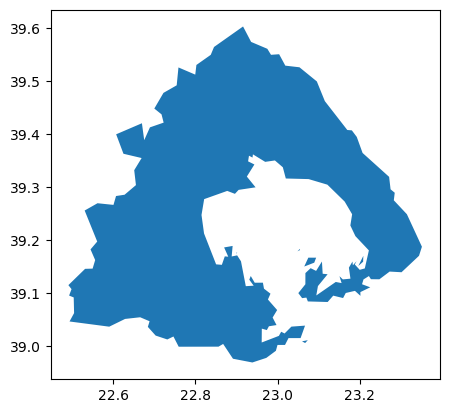

In [ ]:
per_enotites = 'data/RegionalUnits2021/RegionalUnits2021.shp'
gdf = gpd.read_file(per_enotites)
gdf["geometry"] = gdf.geometry.simplify(500, preserve_topology=True)# simplify γεωμετρίας για ταχύτερη απόδοση

if gdf.crs != "EPSG:4326":
    print(f"Reprojecting from {gdf.crs} to EPSG:4326")
    gdf = gdf.to_crs("EPSG:4326") # reproject σε WGS84


#gdf_pe = gdf[gdf["NAME_GR"] == "ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ"] # φίλτρο για συγκεκριμένη περιφερειακή ενότητα
REG_list = ["ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ"]
gdf_pe = gdf[gdf["NAME_GR"].isin(REG_list)]

gdf_pe.plot()



Στην συνέχεια θα ανακτηθούν οι απαραίτητες εικόνες από το collection Sentinel-2 L2A (SENTINEL2_L2A) με την μέθοδο *load_collection()* για το έτος 2023 και για την περιοχή που ορίζεται από τα ακραία σημεία του αρχείου των ΠΕ. 

Επιπλέον ορίζονται οι απαραίτητες μπάντες που χρειάζονται για τον υπολογισμό του NDVI (red = "B04", nir="B08") καθώς και η Scene Classification Layer (μπάντα SCL) που θα χρησιμοποιηθεί για το masking των δορυφορικών εικόνων με διάφορα κριτήρια. Κατά την κλήση της μεθόδου ο χρήστης μπορεί να ορίσει και το όρισμα max_cloud_cover που αφορά την μέγιστη νεφοκάλυψη των εικόνων που θα ανακτηθούν.

Η κλήση της *load_collection()* επιστρέφει ένα data cube που στην ουσία είναι ένας *ProcessBuilder*. Στο openEO, ο ProcessBuilder είναι ένα εργαλείο (helper) της βιβλιοθήκης Python που επιτρέπει την δόμηση πολύπλοκων μαθηματικών και λογικών διεργασιών με τρόπο που μοιάζει με "κανονική" Python, αλλά στην πραγματικότητα μεταφράζεται σε εντολές που καταλαβαίνει ο server (backend).

In [52]:
start_date, end_date = "2023-01-01", "2024-01-01"
bands =["B04", "B08", "SCL"]
max_cloud_cover = 50



xmin, ymin, xmax, ymax = gdf_pe.total_bounds
bbox = {
    "west": xmin,
    "south": ymin,
    "east": xmax,
    "north": ymax,
    "crs": gdf_pe.crs.to_epsg()
}
roi = json.loads(gdf_pe.to_json()) #  GeoJSON format των πολυγώνων 

# ανάκτηση  ProcessBuilder για τα Sentinel-2 data
cube = conn.load_collection(
    "SENTINEL2_L2A",
    #spatial_extent=bbox,
    temporal_extent=(start_date, end_date),
    bands=bands,
    max_cloud_cover=max_cloud_cover
).filter_spatial(roi)


Η μπάντα Scene Classification Layer (SCL) είναι ένα συνοδευτικό layer του Sentinel-2 level L2A).

Πρόκειται για έναν βοηθητικό χάρτη όπου κάθε pixel έχει μια τιμή που υποδεικνύει την ιδιότητά του (π.χ. σύννεφο, σκιά, βλάστηση, νερό).
Περισσότερα για το εν λόγω dataset εδώ: [https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/)

Κατά την τρέχουσα διαδικασία θα εφαρμοστούν τα παρακάτω φίλτρα (masking) στις εικόνες Sentinel-2 με βάση τα εξής SCL codes:


- 1 Saturated or defective pixel
- 3	Cloud shadows
- 6 Water
- 8	Cloud medium probability
- 9	Cloud high probability
- 10 Thin cirrus


Στόχος είναι να αφαιρεθούν τα "προβληματικά" pixels (σύννεφα, σκιές, νερό κτλ) πριν υπολογιστεί ο δείκτης NDVI.


In [53]:
# Ανάκτηση της SCL μπάντας για δημιουργία μάσκας
scl_band = cube.band("SCL")



# https://open-eo.github.io/openeo-python-client/api-processes.html#openeo.processes.array_contains
mask_values = [1, 3, 6, 8, 9, 10] # τα SLC values που αντιστοιχούν σε ανεπιθύμητες τιμές (1, 3, 6, 8, 9, 10)

# εδώ χρησιμοποείται ο ProcessBuilder (μέσω της lambda function). 
# Για κάθε pixel της εικόνας, ο server ελέγχει αν η τιμή αυτού του pixel περιέχεται στη λίστα mask_values;
# Αν Ναι, το pixel γίνεται True (θα καλυφθεί).
# Αν Όχι, γίνεται False (θα παραμείνει).

mask = scl_band.apply(lambda x: array_contains(data=mask_values, value=x))

# ή εναλλακτικά:
#mask = (scl_band == 1) | (scl_band == 3) | (scl_band == 6) | (scl_band == 8) | (scl_band == 9) | (scl_band == 10)

# Η SCL έχει resolution 20m ενώ οι B04/B08 έχουν resolution 10m.
# θα πρέπει να κάνουμε resample την μάσκα για να ταιριάζει με την χωρική ανάλυση των άλλων μπαντών πριν την εφαρμόσουμε ως μάσκα στο cube.

mask_resampled = mask.resample_cube_spatial(cube)

# πλέον μας ενδιαφέρουν μόνο οι B04 και B08 για τον υπολογισμό του NDVI, οπότε φιλτράρουμε το cube για να κρατήσουμε μόνο αυτές τις μπάντες.
cube = cube.filter_bands(["B04", "B08"])

# εφαρμογή της μάσκας στο cube: τα pixels που είναι True στην μάσκα θα καλυφθούν (masked out) και δεν θα επηρεάσουν τους υπολογισμούς μας.
cube = cube.mask(mask) #mask_resampled


Στην συνέχεια ακολουθεί ο υπολογισμός του NDVI. Το openEO API διαθέτει ενσωματωμένη συνάρτηση (όπως το GEE) για τον υπολογισμό του ndvi, περισσότερα εδώ:
https://processes.openeo.org/#ndvi

Όπως φαίνεται δέχεται σαν ορίσματα τις μπάντες red και nir και το όνομα της output μπάντας (target_band).


Το ndvi cube που αποδίδεται είναι το ndvi που προέκυψε για κάθε εικόνα του αρχικού cube.

In [54]:
# υπολογισμός NDVI: (NIR - Red) / (NIR + Red)
ndvi = cube.ndvi(nir="B08", red="B04", target_band="NDVI").filter_bands(["NDVI"])

# κρατάμε τα NDVI values στο εύρος [-1, 1]
ndvi = ndvi.apply(lambda x: clip(x, min=-1, max=1))


Στο επόμενο βήμα στόχος είναι να γίνει μια χρονική συγχώνευση με βάση την μέθοδο *[aggregate_temporal_period()](https://processes.openeo.org/#aggregate_temporal_period)* όπου για κάθε μήνα θα υπολογιστεί ο διάμεσος από τις επιμέρους εικόνες.

In [55]:
# Aggregate to monthly median


monthly_cube = ndvi.aggregate_temporal_period(
    period="month",
    reducer="median"
)




Στην συνέχεια υπολογίζονται τα στατιστικά ζωνών. Τα πολύγωνα του geopandas dataframe πρέπει να μετατραπούν σε geojson αρχείο για να είναι συμβατό σαν όρισμα στο process του openeo api. Για κάθε γεωμετρία που αντιστοιχεί σε ΠΕ υπολογίζουμε το μέσο NDVI μέσω του [aggregate_spatial()](https://processes.openeo.org/#aggregate_spatial) που εφαρμόζει χωρική συγχώνευση με  reducer="mean". Στην ουσία ζητάμε η εκτέλεση αυτή να γίνει στο απομακρυσμένο server και να αποθηκεύσει το αποτέλεσμα σε ένα αρχείο CSV. Αυτό γίνεται με την δημιουργί και ενός batch job με την μέθοδο [create_job()](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.datacube.DataCube.create_job) και η εκκίνηση του υπολογισμού μέσω του [start()](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.job.BatchJob.start)

In [56]:
# μετατροπή των γεωμετριών του GeoDataFrame σε json ώστε να χρησιμοποιηθεί από το OpenEO 
geometries = json.loads(gdf_pe[['geometry']].to_json())

zonal_mean = monthly_cube.aggregate_spatial(
    geometries=geometries,
    reducer="mean"
)

#job = zonal_mean.execute_batch(out_format="CSV", title="Mean NDVI Zonal Statistics)


result = zonal_mean.save_result(format ='CSV')

job = result.create_job(title="Mean NDVI Zonal Statistics")
job.start()

<BatchJob job_id='j-2604151320464ffead2b5a0029486f2b'>

Αφού έχει υποβληθεί προς εκτέλεση η διαδικασία, τότε ο χρήστης μπορεί να λάβει πληροφορίες για αυτήν μέσω του *describe()*. Σημαντική ιδιότητα ενός job είναι το *status*.


Το status του batch job μπορεί να λάβει τις παρακάτω τιμές:

- created:	Η εργασία έχει δημιουργηθεί αλλά δεν έχει ξεκινήσει ακόμα.
- queued:	Η εργασία είναι στην ουρά και περιμένει διαθέσιμους πόρους στον server.
- running:	Ο server επεξεργάζεται τα δεδομένα σου αυτή τη στιγμή και τρέχει τα processes.
- finished:	Επιτυχής ολοκλήρωση. Τα δεδομένα είναι έτοιμα για download.
- error:	    Σφάλμα κατά την εκτέλεση

Στην διεύθυνση [https://openeo.dataspace.copernicus.eu/](https://openeo.dataspace.copernicus.eu/) ο χρήστης μπορεί να παρακολουθεί την εξέλιξη του batch job.

Αν έχει ολοκληρωθεί η διαδικασία στην συνέχεια μπορεί να τρέξει τον παρακάτω κώδικα ώστε να λάβει το αποτέλεσμα ως CSV σε ένα τοπικό directory. 

In [ ]:
output_folder  = OUTPUT_DIR / "zonal_stats"
output_folder.mkdir(parents=True, exist_ok=True)

job = conn.job(job.job_id)

if job.status() == "finished":
        
    results = job.get_results()
    results.download_files(output_folder, include_stac_metadata=False)

Αντί για job.start() ο χρήστης μπορεί να χρησιμοποιήσει την μέθοδο [job.start_and_wait()](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.job.BatchJob.start_and_wait). Η μέθοδος αυτή είναι πιο απλός τρόπος για την διαχείριση ενός Batch Job στο openEO. Αντί να ελέγχει ο χρήστης αν τελείωσε η επεξεργασία (όπως παραπάνω), η μέθοδος αυτή αναλαμβάνει όλη τη δουλειά αυτόματα.


## Λήψη δεδομένων από παλαίοτερο job

Ο χρήστης έχει την δυνατότητα να λάβει πληροφορίες για ένα παλαιότερο job και να κατεβάσει τα αποτελέσματά του.
Αρχικά μπορεί να πάρει πληροφορίες για τα παλιότερα jobs όπως title, id και status.

In [75]:
jobs = conn.list_jobs()

for j in jobs:
    if 'title' in j:
        print(f"Title: {j['title']} | ID: {j['id']} | Status: {j['status']}")
    else:
        print(f"ID: {j['id']} | Status: {j['status']}")

Title: Monthly_NDVI_NetCDF | ID: j-2604151115354ae887f78fc7fd92a0f6 | Status: created
Title: Mean NDVI Zonal Statistics | ID: j-260415103329475291d1ccd7de0c6636 | Status: finished
Title: Mean NDVI Zonal Statistics | ID: j-2604150853544345ba3a73d707a1ae8c | Status: error
Title: Mean NDVI Zonal Statistics | ID: j-26041508440248e3810f70ea654cdff3 | Status: finished
Title: Mean NDVI Zonal Statistics | ID: j-26041508315446a0873b25fb9188adf0 | Status: finished
Title: Mean NDVI Zonal Statistics | ID: j-260415071842430fa98727e338096622 | Status: error
Title: Mean NDVI Zonal Statistics | ID: j-2604150628364893b477fa8474249e63 | Status: error
Title: Mean NDVI Zonal Statistics | ID: j-26041419165947b08864cd2858ce4e8e | Status: finished
Title: Mean NDVI Zonal Statistics | ID: j-2604141727444f12b8fe4511ac2a43bf | Status: error
Title: Mean NDVI Zonal Statistics | ID: j-26041416362340949a60553174c0e5ec | Status: error
Title: Mean NDVI Zonal Statistics | ID: j-26041415331543d18404028459451514 | Status

Στην συνέχεια μπορεί να χρησιμοποιήσει το ID του job που το ενδιαφέρει και να κατεβάσει το αποτελεσμά του:

In [62]:
TMP_DIR = OUTPUT_DIR / "tmp" 
TMP_DIR.mkdir(exist_ok=True) # δημιουργία του φακέλου αν δεν υπάρχει ήδη

# Ενδεικτικό παράδειγμα, αν γνωρίζουμε το job_id μπορούμε να ελέγξουμε την κατάσταση του job 
# και να κατεβάσουμε τα αποτελέσματα όταν είναι έτοιμα

job_id = 'j-2604111011274afd915f623b317ce5ac'
job = conn.job(job_id)

if job.status() == "finished":
        
    results = job.get_results()
    results.download_files(TMP_DIR, include_stac_metadata=False)

## Εξαγωγή εικόνων από το CDSE

Στο επόμενο παράδειγμα θα γίνει εξαγωγή των εικόνων των μηνιαίων σύνθετων NDVI για μια ΠΕ. Οι εικόνες θα αποκοπούν (clip) στα όρια του πολυγώνου της ΠΕ με τη μέθοδο [filter_spatial()](https://open-eo.github.io/openeo-python-client/api-processes.html#openeo.processes.filter_spatial) και στην συνέχεια θα γίνουν reprojection στον ΕΓΣΑ'87, με χωρική διακριτική ικανότητα στα 100μ μέσω της μεθόδου [resample_spatial()](https://open-eo.github.io/openeo-python-client/api-processes.html#openeo.processes.resample_spatial).

Το αποτέλεσμα θα αποθηκευτεί σε αρχείο NetCDF, ένας μορφότυπος αρχείου που σχεδιάστηκε ειδικά για την αποθήκευση πολυδιάστατων επιστημονικών δεδομένων. Φυσικά υπάρχει και η δυνατότητα λήψης του αποτελέσματος σαν μεμονωμένα geotiffs, αρκεί να οριστεί:

```
save_result(
    format="GTiff",
    options={"separate_tiffs": True} 
)
```


In [63]:
geometry = gdf_pe.geometry.union_all().__geo_interface__ # λήψη της γεωμετρίας της ΠΕ ως GeoJSON dictionary
ndvi_resampled = monthly_cube.filter_spatial(geometry) # αποκοπή στην γεωμετρία της περιοχής ενδιαφέροντος

# reprojection στο ΕΓΣΑ87 και resample σε 100m ανάλυση
ndvi_resampled = monthly_cube.resample_spatial(resolution=100, projection="EPSG:2100")

output_folder = OUTPUT_DIR / "monthly_ndvi"
output_folder.mkdir(parents=True, exist_ok=True)

# προετοιμασία του result με NetCDF format
result_node = ndvi_resampled.save_result(format="NetCDF")

# δημιουργία και εκτέλεση του batch job
job = result_node.create_job(title="Monthly_NDVI_NetCDF")
job.start_and_wait()

# λήψη των αποτελεσμάτων
results = job.get_results()
output_path = results.download_files(output_folder, include_stac_metadata=False)
output_path

0:00:00 Job 'j-2604151331014bcb8ab8b93bb454d819': send 'start'
0:00:20 Job 'j-2604151331014bcb8ab8b93bb454d819': queued (progress 0%)
0:00:26 Job 'j-2604151331014bcb8ab8b93bb454d819': queued (progress 0%)
0:00:33 Job 'j-2604151331014bcb8ab8b93bb454d819': queued (progress 0%)
0:00:41 Job 'j-2604151331014bcb8ab8b93bb454d819': queued (progress 0%)
0:00:51 Job 'j-2604151331014bcb8ab8b93bb454d819': queued (progress 0%)
0:01:05 Job 'j-2604151331014bcb8ab8b93bb454d819': queued (progress 0%)
0:01:21 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)
0:01:40 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)
0:02:04 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)
0:02:34 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)
0:03:12 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)
0:03:59 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)
0:04:59 Job 'j-2604151331014bcb8ab8b93bb454d819': running (progress N/A)


[PosixPath('output/CDSE/monthly_ndvi/openEO.nc')]

Στην συνέχεια μπορούμε να διαβάσουμε το αρχείο NetCDF μέσω της βιβλιοθήκης [xarray](https://docs.xarray.dev/en/stable/). Το xarray είναι μια βιβλιοθήκη της Python που κάνει τη διαχείριση πολυδιάστατων πινάκων (multidimensional arrays) εύκολη και αποδοτική, προσθέτοντας ετικέτες (labels) στις διαστάσεις.

<xarray.Dataset> Size: 27MB
Dimensions:  (t: 12, x: 766, y: 728)
Coordinates:
  * t        (t) datetime64[ns] 96B 2023-01-01 2023-02-01 ... 2023-12-01
  * x        (x) float64 6kB 3.689e+05 3.69e+05 ... 4.453e+05 4.454e+05
  * y        (y) float64 6kB 4.385e+06 4.385e+06 ... 4.313e+06 4.312e+06
Data variables:
    crs      |S1 1B ...
    NDVI     (t, y, x) float32 27MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.71.0a28.dev2...
    description:  
    title:        
Data variables:
    crs      |S1 1B ...
    NDVI     (t, y, x) float32 27MB ...


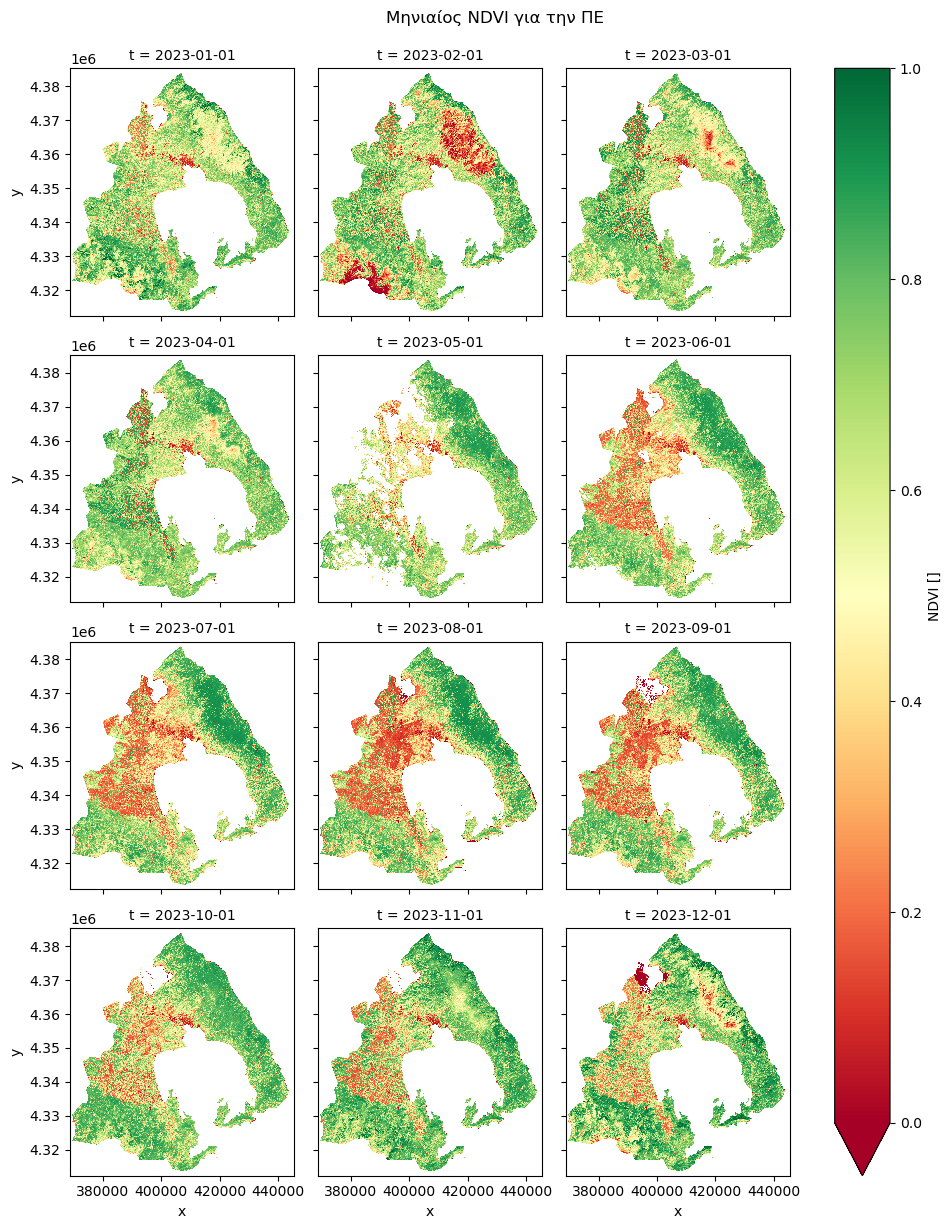

In [65]:
# ανάγνωση του αρχείου
ds = xr.open_dataset(str(output_path[0]))

# προβολή του dataset και των διαθέσιμων data variables 
print(ds)
print(ds.data_vars)

# οπτικοποίηση του NDVI ανά μήνα στην ΠΕ
ds.NDVI.plot(
    col="t", 
    col_wrap=3, 
    cmap="RdYlGn", 
    vmin=0, 
    vmax=1
)

plt.suptitle("Μηνιαίος NDVI για την ΠΕ", y=1.02)
plt.show()



Χάρη στην ευχέρια που προσφέρει το xarray μπορούμε μεμονωμένα να οπτικοποιήσουμε τα δεδομένα στην ΠΕ από έναν μόνο μήνα αν θέλουμε ή να κάνουμε ένα γράφημα της διαχρονική εξέλιξης του μέσου NDVI στην ΠΕ.

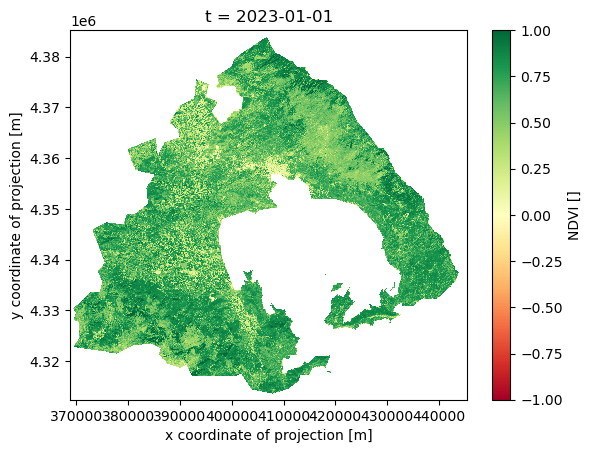

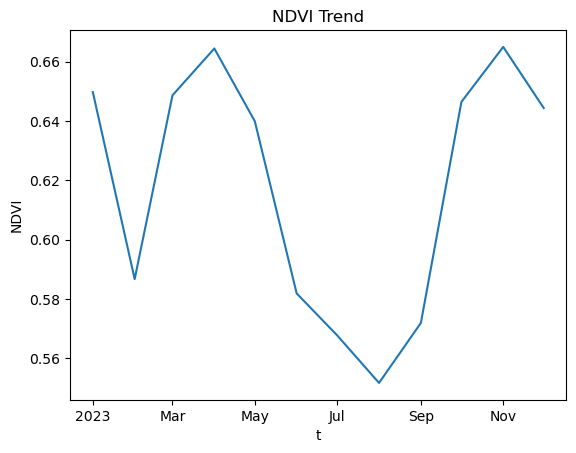

In [66]:

# εκτύπωση του NDVI για τον πρώτο μήνα (πρώτο χρονικό βήμα) 
ds.NDVI.isel(t=0).plot(cmap="RdYlGn")
plt.show()

# οπτικοποίηση της χρονικής εξέλιξης του μέσου NDVI στην ΠΕ (regional trend)
ds.NDVI.mean(dim=["x", "y"]).plot()
plt.title("NDVI Trend")
plt.show()

Πιο διαδραστική οπτικοποίηση προσφέρει η βιβλιοθήκη [hvplot](https://hvplot.holoviz.org/en/docs/latest/index.html).

In [67]:
# Δημιουργία ιστογράμματος των NDVI τιμών για τον πρώτο μήνα
ds.NDVI.isel(t=0).hvplot.hist(bins=20, title="NDVI Distribution for First Month", xlabel="NDVI", ylabel="Frequency")


:NdOverlay   [Variable]
   :Histogram   [NDVI]   (Count)

In [68]:
ds.NDVI.isel(t=0).hvplot(x="x", y="y", cmap="RdYlGn",    
                        width=500,   # Πλάτος σε pixels
                        height=400)  # Ύψος σε pixels # διαδραστική οπτικοποίηση του NDVI για τον πρώτο μήνα

:Image   [x,y]   (NDVI)

In [69]:
ds.NDVI.hvplot(
    groupby="t",  #     δημιουργία ενός widget για κάθε χρονικό βήμα (μήνα)
    clim=(-1,1),  # όριο για το χρωματικό χάρτη
    widget_type="scrubber", # τύπος widget για την επιλογή του χρονικού βήματος
    widget_location="bottom",x="x", y="y", cmap="RdYlGn" ,
    width=500,   # Πλάτος σε pixels
    height=400   # Ύψος σε pixels
)


BokehModel(combine_events=True, render_bundle={'docs_json': {'4703a3f8-3c75-4c52-950a-181939366c9d': {'version…

Επιπλέον ο χρήστης μπορεί να οπτικοποιήσει τα δεδομένα σε έναν χάρτη leaflet.

In [73]:
# επιλογή του NDVI για τον πρώτο μήνα (πρώτο χρονικό βήμα) και υπολογισμός του
ndvi = ds.NDVI.compute()


# ορισμός του CRS του NDVI dataset σε ΕΓΣΑ87 (EPSG:2100)
ndvi.rio.write_crs("EPSG:2100", inplace=True)

# αλλαγή του CRS σε WGS84 για χρήση με το Folium
ndvi = ndvi.rio.reproject("EPSG:4326")


# μεσος όρος των συντεταγμένων για κεντράρισμα του χάρτη
center_lat = float(ndvi.y.mean())
center_lon = float(ndvi.x.mean())

m = leafmap.Map(center=[center_lat, center_lon], zoom=12)

m.add_raster(ndvi, layer_name="NDVI Index", cmap="RdYlGn", nodata=np.nan) 

m

Map(center=[39.2854595, 22.9228425], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…